In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

filename = 'Training_Frame1_PC.tif'
image_path = './movies/'
files = [image_path + filename] 

2024-09-18 20:49:10,068	[INFO]     omnipose/gpu.py               <module>....()	 line   9	On ARM, OMP_NUM_THREADS set to 1


Original image shape: (2044, 2048)
data type: uint16
data range: min 1413, max 3602


number of images: 1


new shape:  (2044, 2048)


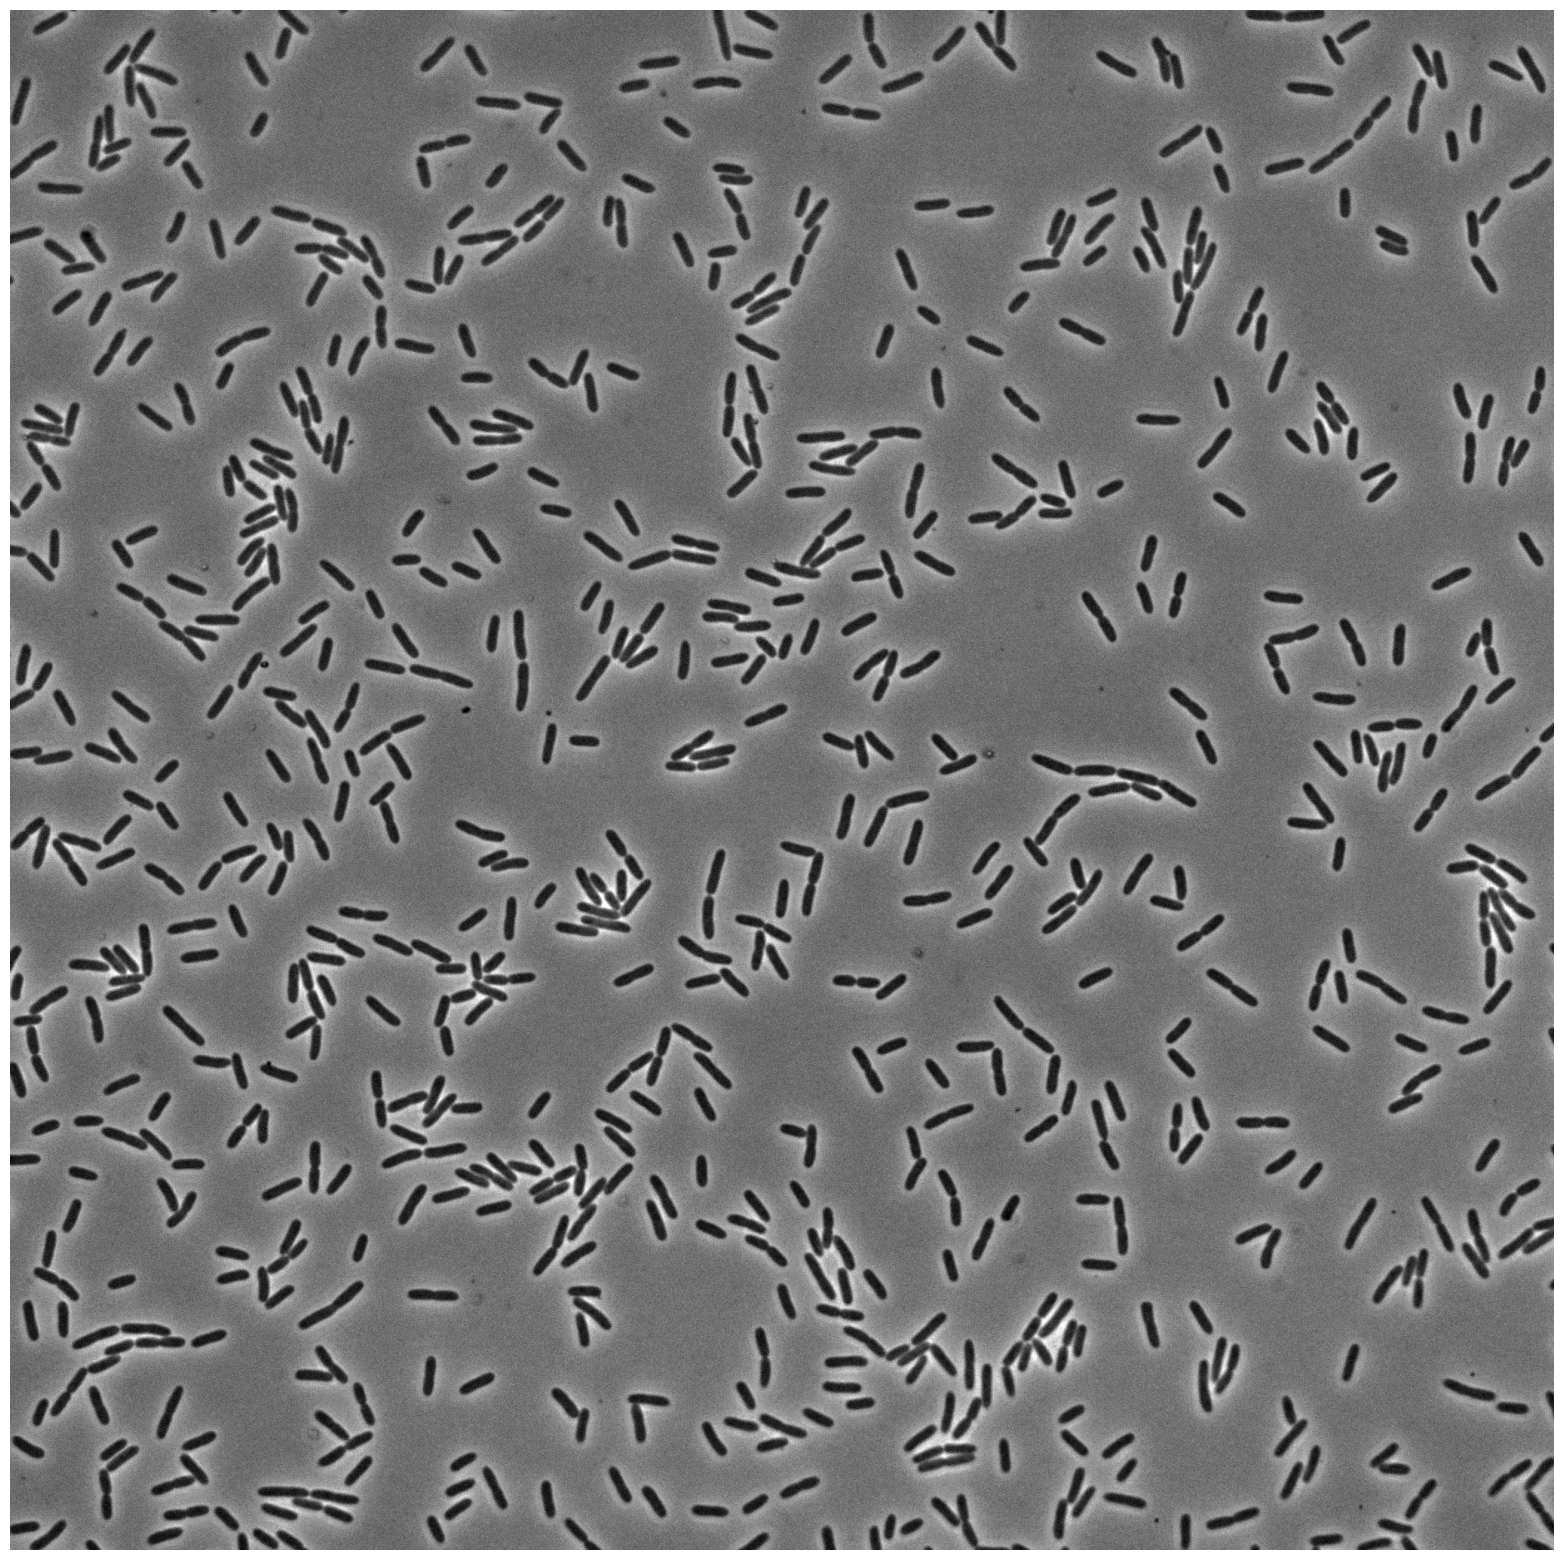

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from cellpose_omni import io, transforms
from omnipose.utils import normalize99
imgs = [io.imread(f) for f in files]

# print some info about the images.
for i in imgs:
    print('Original image shape:',i.shape)
    print('data type:',i.dtype)
    print('data range: min {}, max {}\n'.format(i.min(),i.max()))
nimg = len(imgs)
print('\nnumber of images:',nimg)

fig = plt.figure(figsize=[20]*2,frameon=False) # initialize figure
print('\n')
for k in range(len(imgs)):
    img = transforms.move_min_dim(imgs[k]) # move the channel dimension last
    if len(img.shape)>2:
        # imgs[k] = img[:,:,1] # could pick out a specific channel
        imgs[k] = np.mean(img,axis=-1) # or just turn into grayscale 
        
    imgs[k] = normalize99(imgs[k])
    # imgs[k] = np.pad(imgs[k],10,'edge')
    print('new shape: ', imgs[k].shape)
    plt.subplot(1,len(files),k+1)
    plt.imshow(imgs[k],cmap='gray')
    plt.axis('off')

In [9]:
import torch
from torch.cuda import is_available as tc_available
print('>>> Pytorch can access cuda GPU support?',tc_available())

>>> Pytorch can access cuda GPU support? False


In [13]:
import cellpose_omni

use_GPU = core.use_gpu()
print('>>> GPU activated? {}'.format(use_GPU))

>>> GPU activated? (device(type='mps', index=0), True)


In [14]:
MODEL_NAMES

['bact_phase_omni',
 'bact_fluor_omni',
 'worm_omni',
 'worm_bact_omni',
 'worm_high_res_omni',
 'cyto2_omni',
 'plant_omni',
 'bact_phase_cp',
 'bact_fluor_cp',
 'plant_cp',
 'worm_cp',
 'cyto',
 'nuclei',
 'cyto2']

In [15]:
model_name = 'bact_phase_omni'
model = models.CellposeModel(gpu=use_GPU, model_type=model_name)

2024-09-18 20:51:43,243	[INFO]     cellpose_omni/models.py                   	 line 432	>>bact_phase_omni<< model set to be used
2024-09-18 20:51:43,248	[INFO]     cellpose_omni/core.py         assi...evice()	 line  67	Using GPU.
2024-09-18 20:51:43,336	[INFO]                                   __init__....()	 line 163	u-net config: ([2, 32, 64, 128, 256], 4, 2)


In [16]:
import time
chans = [0,0] #this means segment based on first channel, no second channel 

n = [0] # make a list of integers to select which images you want to segment

# define parameters
params = {'channels':chans, # always define this with the model
          'rescale': None, # upscale or downscale your images, None = no rescaling 
          'mask_threshold': 1.75, # erode or dilate masks with higher or lower values between -5 and 5 
          'flow_threshold': 0.4, # default is .4, but only needed if there are spurious masks to clean up; slows down output
          'transparency': True, # transparency in flow output
          'omni': True, # we can turn off Omnipose mask reconstruction, not advised 
          'cluster': True, # use DBSCAN clustering
          'resample': True, # whether or not to run dynamics on rescaled grid or original grid 
          'verbose': False, # turn on if you want to see more output 
          'tile': False, # average the outputs from flipped (augmented) images; slower, usually not needed 
          'niter': None, # default None lets Omnipose calculate # of Euler iterations (usually <20) but you can tune it for over/under segmentation 
          'augment': False, # Can optionally rotate the image and average network outputs, usually not needed 
          'affinity_seg': False, # new feature, stay tuned...
         }

tic = time.time() 
masks, flows, styles = model.eval(imgs,**params)

net_time = time.time() - tic

print('total segmentation time: {}s'.format(net_time))

total segmentation time: 3.496711254119873s


In [17]:
io.save_masks(imgs, masks, flows, files, 
              png=False,
              tif=True, # whether to use PNG or TIF format
              suffix='', # suffix to add to files if needed 
              save_flows=False, # saves both RGB depiction as *_flows.png and the raw components as *_dP.tif
              save_outlines=True, # save outline images 
              dir_above=1, # save output in the image directory or in the directory above (at the level of the image directory)
              in_folders=True, # save output in folders (recommended)
              save_txt=False, # txt file for outlines in imageJ
              save_ncolor=False) # save ncolor version of masks for visualization and editing 


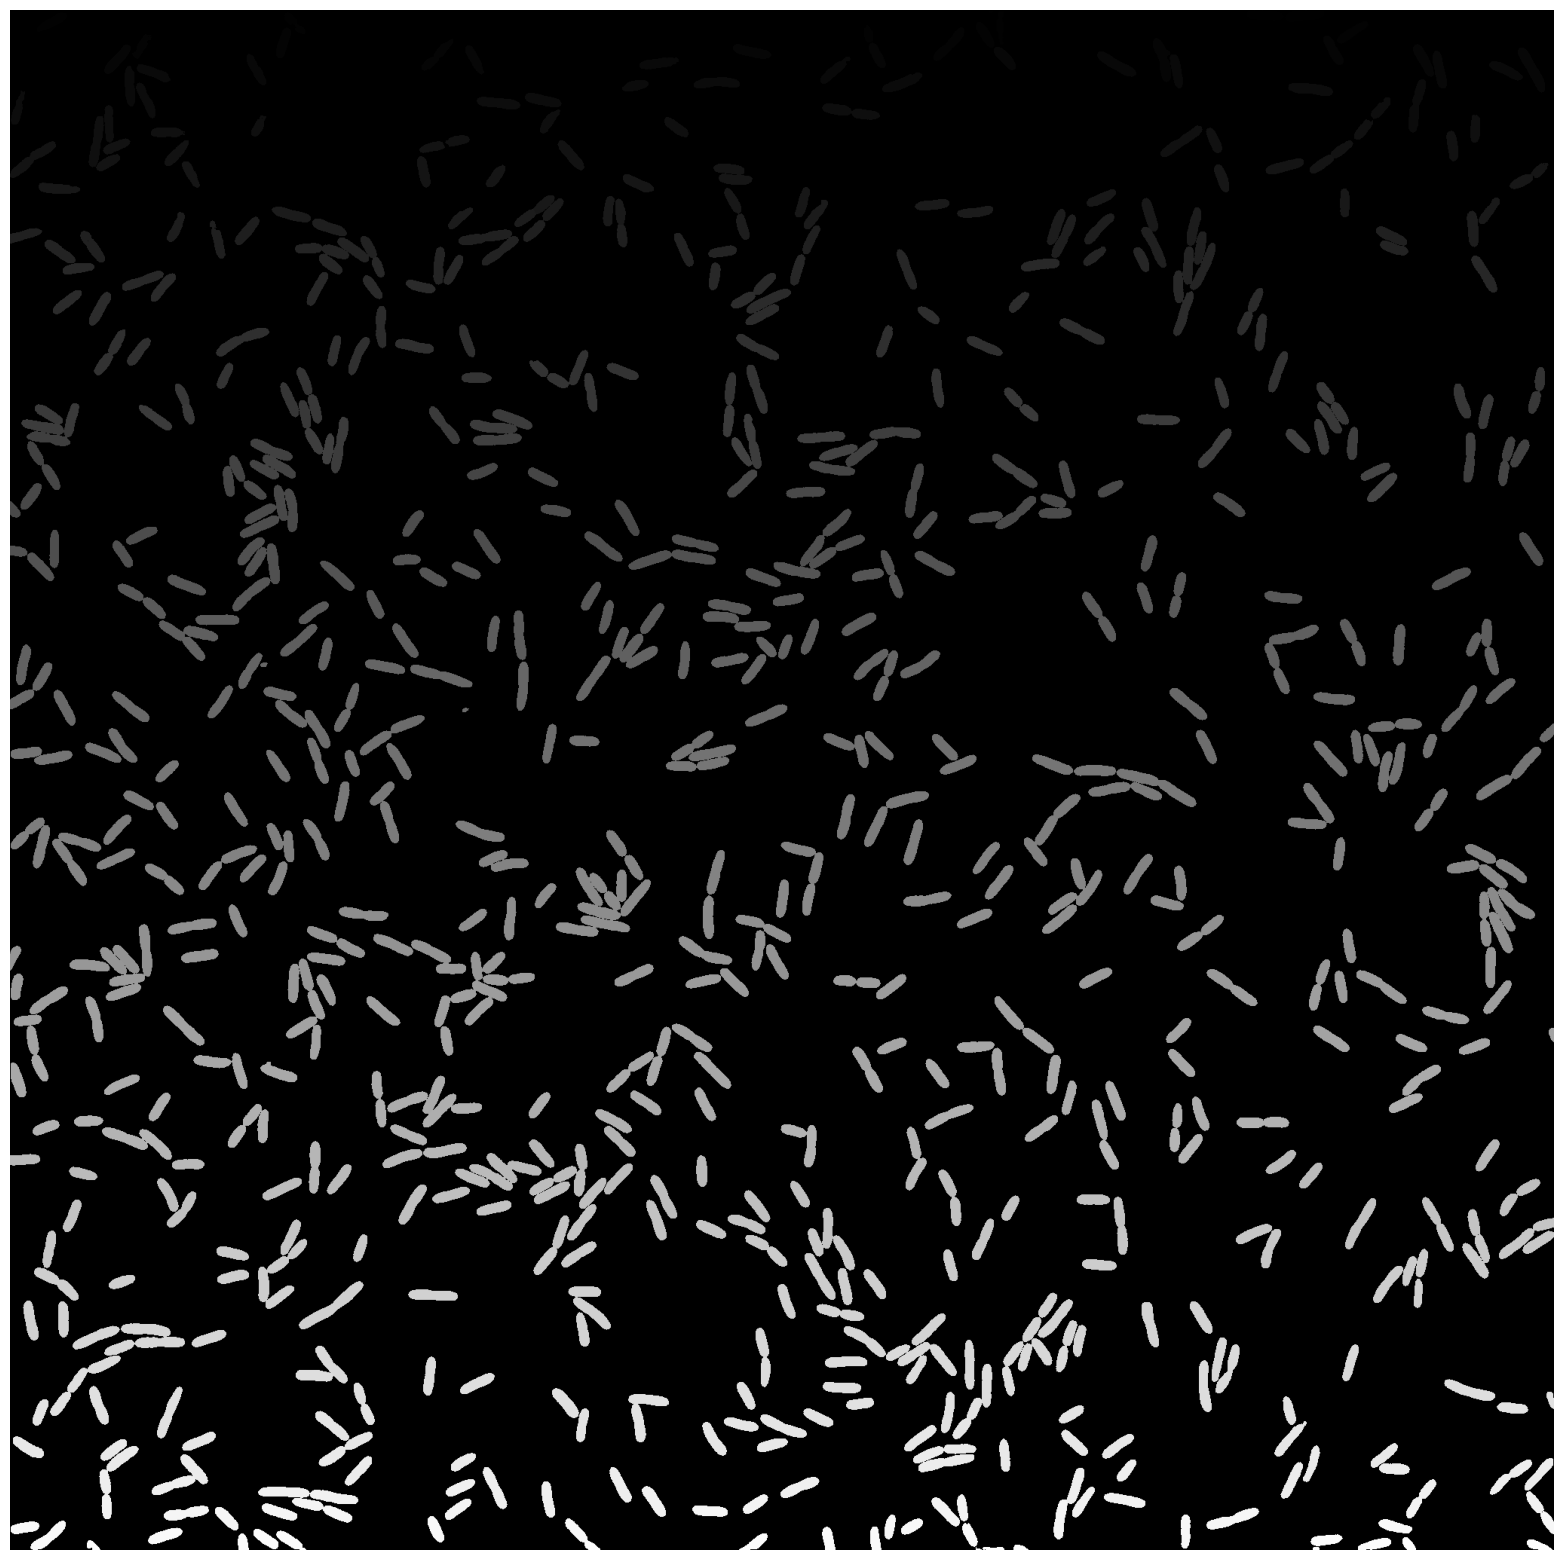

In [18]:
maski = masks[0] # get masks
bdi = flows[0][-1] # get boundaries

fig = plt.figure(figsize=[20]*2,frameon=False) 
imgs[0] = normalize99(imgs[0])
plt.imshow(maski,cmap='gray')

plt.axis('off')

plt.show()